In [13]:
from sklearn.manifold import MDS
import numpy as np

In [14]:
coords = [
    np.array([
    [0.0, 0.0],
    [25.0, 0.0],
    [0.0, 25.0],
    [25.0, 25.0],
    [12.0, 5.0],
    [5.0, 18.0],
    [20.0, 3.0],
    [3.0, 22.0],
    [18.0, 20.0],
    [8.0, -5.0],
    ]),
    np.array([
    [2.0, 2.0],
    [25.0, 0.0],
    [0.0, 25.0],
    [25.0, 25.0],
    [12.0, 5.0],
    [5.0, 18.0],
    [20.0, 3.0],
    [3.0, 22.0],
    [18.0, 20.0],
    [8.0, -5.0],
    ]),
    np.array([
    [4.0, 4.0],
    [25.0, 0.0],
    [0.0, 25.0],
    [25.0, 25.0],
    [12.0, 5.0],
    [5.0, 18.0],
    [20.0, 3.0],
    [3.0, 22.0],
    [18.0, 20.0],
    [8.0, -5.0],
    ]),
    np.array([
    [8.0, 8.0],
    [25.0, 0.0],
    [0.0, 25.0],
    [25.0, 25.0],
    [12.0, 5.0],
    [5.0, 18.0],
    [20.0, 3.0],
    [3.0, 22.0],
    [18.0, 20.0],
    [8.0, -5.0],
    ]),
    np.array([
    [16.0, 16.0],
    [25.0, 0.0],
    [0.0, 25.0],
    [25.0, 25.0],
    [12.0, 5.0],
    [5.0, 18.0],
    [20.0, 3.0],
    [3.0, 22.0],
    [18.0, 20.0],
    [8.0, -5.0],
    ]),
]

diff = [coord[:, None, :] - coord[None, :, :] for coord in coords]
X = [np.linalg.norm(d, axis=2) for d in diff]
X[0]

array([[ 0.        , 25.        , 25.        , 35.35533906, 13.        ,
        18.68154169, 20.22374842, 22.20360331, 26.90724809,  9.43398113],
       [25.        ,  0.        , 35.35533906, 25.        , 13.92838828,
        26.90724809,  5.83095189, 31.11269837, 21.1896201 , 17.72004515],
       [25.        , 35.35533906,  0.        , 25.        , 23.32380758,
         8.60232527, 29.73213749,  4.24264069, 18.68154169, 31.04834939],
       [35.35533906, 25.        , 25.        ,  0.        , 23.85372088,
        21.1896201 , 22.56102835, 22.20360331,  8.60232527, 34.4818793 ],
       [13.        , 13.92838828, 23.32380758, 23.85372088,  0.        ,
        14.76482306,  8.24621125, 19.23538406, 16.15549442, 10.77032961],
       [18.68154169, 26.90724809,  8.60232527, 21.1896201 , 14.76482306,
         0.        , 21.21320344,  4.47213595, 13.15294644, 23.19482701],
       [20.22374842,  5.83095189, 29.73213749, 22.56102835,  8.24621125,
        21.21320344,  0.        , 25.49509757

In [92]:
rand_coords = np.random.rand(100, 10, 2) * 25.0
rand_diffs = [coord[:, None, :] - coord[None, :, :] for coord in rand_coords]
X_rand = [np.linalg.norm(d, axis=2) for d in rand_diffs]
X_rand[0]

array([[ 0.        , 18.21973185, 15.79121621,  8.74513567, 16.72758219,
         3.8095357 ,  7.04752762,  6.57706187,  2.45276292, 21.19653192],
       [18.21973185,  0.        ,  6.86527874, 16.2451375 , 24.21727298,
        15.28704947, 12.25825926, 12.18038276, 19.42851986,  5.62059978],
       [15.79121621,  6.86527874,  0.        , 10.8649714 , 17.68071339,
        12.12667589, 12.19775992,  9.22963839, 17.69142829,  5.96250463],
       [ 8.74513567, 16.2451375 , 10.8649714 ,  0.        ,  9.5005276 ,
         5.64039736, 11.11110555,  6.10579992, 11.19773506, 16.82281097],
       [16.72758219, 24.21727298, 17.68071339,  9.5005276 ,  0.        ,
        14.68942259, 20.56464391, 15.60493328, 18.99688442, 23.02008224],
       [ 3.8095357 , 15.28704947, 12.12667589,  5.64039736, 14.68942259,
         0.        ,  6.20224173,  3.13218893,  6.08375895, 17.71403664],
       [ 7.04752762, 12.25825926, 12.19775992, 11.11110555, 20.56464391,
         6.20224173,  0.        ,  5.18159455

In [98]:
from sklearn.metrics import mean_absolute_error

## Check different number of iterations

iterations = [
    10,
    20,
    50,
    70,
    80,
    90,
    100
]
results = []

for x in X_rand:
    x_results = []
    for it in iterations:
        model = MDS(n_components=2, dissimilarity="precomputed", max_iter=it, normalized_stress=True)
        res = model.fit_transform(x)
        x_results.append({
            "stress": model.stress_,
            "iter": model.n_iter_,
            "iterations": it
        })
    [results.append(x) for x in x_results]
results.sort(key=lambda x: x["iter"])

/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/sit

In [99]:
avg_results = []
sum = 0
iter_start_idx = 0
for idx, res in enumerate(results):
    if idx == 0 or res["iter"] == results[idx - 1]["iter"]:
        sum += res["stress"]
    else:
        avg_results.append({
            "stress": (sum / (idx - iter_start_idx)),
            "iter": results[idx - 1]["iter"]
        })
        iter_start_idx = idx
        sum = res["stress"]

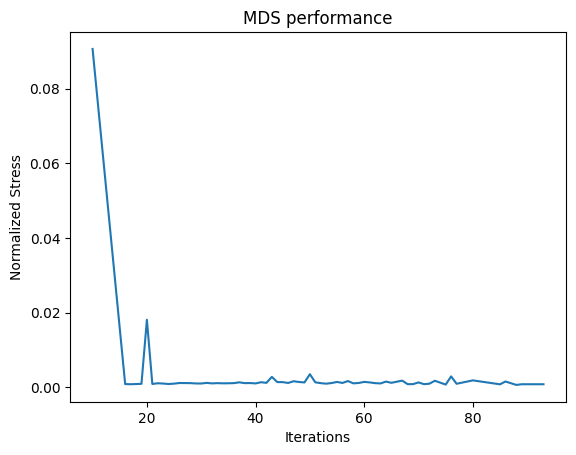

In [100]:
import matplotlib.pyplot as plt

plt.title("MDS performance")
plt.xlabel("Iterations")
plt.ylabel("Normalized Stress")
plt.plot([r["iter"] for r in avg_results], [r["stress"] for r in avg_results])

In [102]:
results = []

for idx, x in enumerate(X):
    model = MDS(n_components=2, dissimilarity="precomputed", max_iter=80, normalized_stress=True)
    res = model.fit_transform(x)
    res = np.c_[res, np.zeros(res.shape[0])]
    results.append(res)


/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/sit

In [103]:
results

[array([[  8.01952562,  14.07255343,   0.        ],
        [ 14.2912293 , -10.13278476,   0.        ],
        [-16.18864588,   7.77216994,   0.        ],
        [ -9.81089774, -16.45586862,   0.        ],
        [  6.18653434,   1.21681527,   0.        ],
        [ -8.15479272,   4.70716437,   0.        ],
        [ 10.14876582,  -6.01774563,   0.        ],
        [-12.53048773,   5.62654188,   0.        ],
        [ -6.83419575,  -8.36909301,   0.        ],
        [ 14.87296474,   7.58024714,   0.        ]]),
 array([[-12.73795512,   4.87701234,   0.        ],
        [  7.5505109 ,  15.80310563,   0.        ],
        [ -5.57807003, -17.04109487,   0.        ],
        [ 17.45088095,  -7.22246476,   0.        ],
        [ -2.3557669 ,   6.05026728,   0.        ],
        [ -3.67540914,  -8.65557767,   0.        ],
        [  4.23078046,  11.02299813,   0.        ],
        [ -3.9520765 , -13.11914757,   0.        ],
        [  9.05299   ,  -5.38075857,   0.        ],
        [ 

In [104]:
iterative_mds_results = []

for idx, x in enumerate(X):
    model = MDS(n_components=2, dissimilarity="precomputed", max_iter=80)
    init = None if idx == 0 else iterative_mds_results[idx - 1]
    res = model.fit_transform(x, init=init)
    res = np.c_[res, np.zeros(res.shape[0])]
    iterative_mds_results.append(res)


/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/bcsonto/dev/exp/.venv/lib/python3.13/sit

In [105]:
from scipy.spatial.transform import Rotation as R


rotated = [results[0]]
for idx, res in enumerate(results):
    if idx == 0:
        continue
    rot, _ = R.align_vectors(rotated[idx - 1], res)
    rotated.append(rot.apply(res))
    

In [106]:
results[0]

array([[  8.01952562,  14.07255343,   0.        ],
       [ 14.2912293 , -10.13278476,   0.        ],
       [-16.18864588,   7.77216994,   0.        ],
       [ -9.81089774, -16.45586862,   0.        ],
       [  6.18653434,   1.21681527,   0.        ],
       [ -8.15479272,   4.70716437,   0.        ],
       [ 10.14876582,  -6.01774563,   0.        ],
       [-12.53048773,   5.62654188,   0.        ],
       [ -6.83419575,  -8.36909301,   0.        ],
       [ 14.87296474,   7.58024714,   0.        ]])

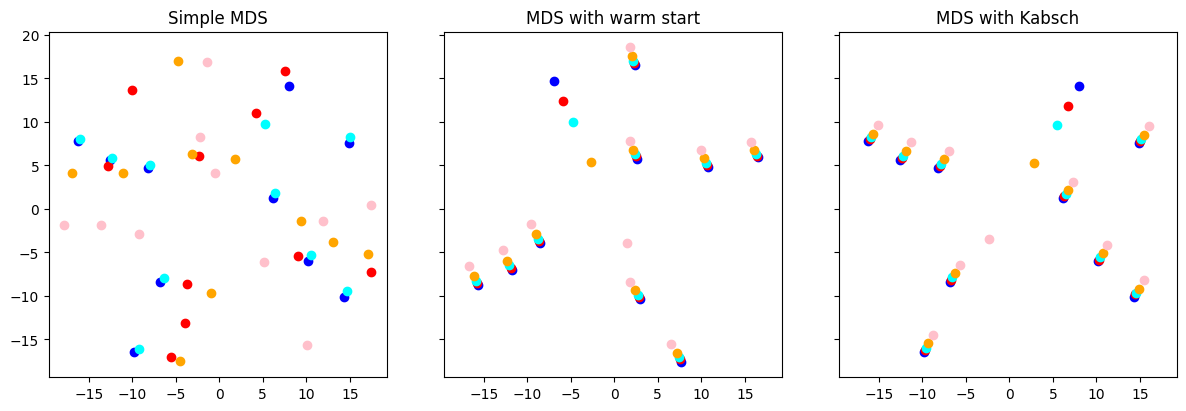

In [113]:
colors = [
    "blue",
    "red",
    "cyan",
    "orange",
    "pink"
]
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    constrained_layout=True,
    sharex=True,
    sharey=True,
    subplot_kw={"aspect": "equal"}
)
for a in ax:
    a.set_aspect('equal', adjustable='box')

ax[0].set_title("Simple MDS")
for idx,r in enumerate(results):
    ax[0].scatter(r[:,0], r[:,1], color=colors[idx])

ax[1].set_title("MDS with warm start")
for idx,x in enumerate(iterative_mds_results):
    ax[1].scatter(x[:,0], x[:,1], color=colors[idx])

ax[2].set_title("MDS with Kabsch")
for idx,r in enumerate(rotated):
    ax[2].scatter(r[:,0], r[:,1], color=colors[idx])


In [ ]:
def pairwise_distances(X) -> np.ndarray:
    pass


def mdd():
    n = 5
    X = np.array([[],[]])
    iterations = 100
    for i in range(iterations):
        dist = pairwise_distances(X)

        B = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    if dist[i,j] > eps:
                        B[i,j] = -D[i,j] / dist[i,j]
                    else:
                        B[i,j] = 0
                else:
                    B[i,i] = -sum(B[i,j] for j != i)

        X = (1/n) * B @ X
        X -= X.mean(axis=0)

In [32]:
ar = np.arange(100).reshape((10,10))
ar.mean(axis=0)

array([45., 46., 47., 48., 49., 50., 51., 52., 53., 54.])

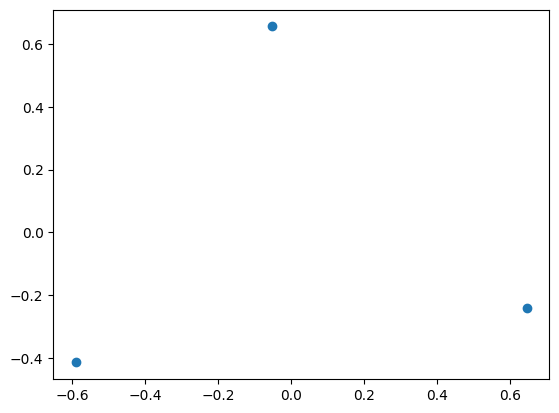

In [7]:
import numpy as np
import matplotlib.pyplot as plt

mds = np.array([[0.6445646, -0.24122998], [-0.59069395, -0.4145346], [-0.053870726, 0.6557646]])

plt.scatter(mds[:,0], mds[:,1])
